<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/feature%2FLSTM/notebooks/3.CONV1D_%2B_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caricamento librerie e dataset

In [1]:
!git clone -b feature/LSTM https://github.com/dokunoale/chagas.git
!pip install -r chagas/requirements.txt

# Download the dataset
import gdown

url = "https://drive.google.com/file/d/1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q /content/dataset.zip -d chagas/data/

Cloning into 'chagas'...
remote: Enumerating objects: 461, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 461 (delta 88), reused 100 (delta 40), pack-reused 270 (from 1)
Receiving objects: 100% (461/461), 5.44 MiB | 20.94 MiB/s, done.
Resolving deltas: 100% (212/212), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 27.2 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: h5py
    Found existing installation: h5py 3.14.0
    Uninstalling h5py-3.14.0:
      Successfully uninstalled h5py-3.14.0
  Attempting uninstall: scikit-learn

Downloading...
From (original): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC
From (redirected): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC&confirm=t&uuid=30db7dfc-4f20-4e58-a9f7-c273328d95e8
To: /content/dataset.zip
100%|██████████| 623M/623M [00:09<00:00, 68.6MB/s]


In [2]:
import sys
sys.path.append("/content/chagas/src")

import os

import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC

import numpy as np
from sklearn.model_selection import train_test_split
from scipy.signal import iirnotch, butter, filtfilt

from preprocessing.tf_dataset_loader import load_dataset, concatenate_and_shuffle
from preprocessing.denoiser import *
from models.utils import *

In [3]:
# Carichiamo il dataset
data_path = "/content/chagas/data/big_splitted_dataset/"

X_train, y_train = concatenate_and_shuffle(
    load_dataset(data_path + "train/positives"),
    load_dataset(data_path + "train/negatives"))

X_val, y_val = concatenate_and_shuffle(
    load_dataset(data_path + "val/positives"),
    load_dataset(data_path + "val/negatives"))

X_test, y_test = concatenate_and_shuffle(
    load_dataset(data_path + "test/positives"),
    load_dataset(data_path + "test/negatives"))

In [4]:
X_train = filtfilt_noise_reduction(X_train, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_val = filtfilt_noise_reduction(X_val, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_test = filtfilt_noise_reduction(X_test, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)

In [5]:
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# MODELLO CNN + GRU

In [6]:
#Definizione del modello

def build_ecg_cnn_gru_model(
    input_shape=(2800, 12),
    gru_units=64,
    dropout_rate=0.3
):
    inputs = layers.Input(shape=input_shape)

    # Blocchi CNN per ridurre la sequenza e trovare pattern locali
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)  # 2800 -> 1400
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)  # 1400 -> 700
    x = layers.Dropout(dropout_rate)(x)

    # Bidirectional GRU
    x = layers.Bidirectional(layers.GRU(gru_units, return_sequences=False))(x)
    x = layers.Dropout(dropout_rate)(x)

    # Dense layers
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model


In [9]:
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC

model = build_ecg_cnn_gru_model(dropout_rate=0.5)

#compiliamo il modello
model.compile(optimizer='adam',
              loss=BinaryCrossentropy(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("GRU")

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32,
                    callbacks=callback)

Epoch 1/50
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5369 - auc: 0.5407 - loss: 0.6921
Epoch 1: val_auc improved from -inf to 0.60881, saving model to LSTM_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.5370 - auc: 0.5408 - loss: 0.6921 - val_accuracy: 0.5838 - val_auc: 0.6088 - val_loss: 0.6800 - learning_rate: 0.0010
Epoch 2/50
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5602 - auc: 0.5853 - loss: 0.6835
Epoch 2: val_auc improved from 0.60881 to 0.67865, saving model to LSTM_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.5604 - auc: 0.5855 - loss: 0.6834 - val_accuracy: 0.6275 - val_auc: 0.6786 - val_loss: 0.6467 - learning_rate: 0.0010
Epoch 3/50
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6270 - auc: 0.6602 - loss: 0.6607
Epoch 3: val_auc improved from 0.67865 to 0.69991, saving model to LSTM_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.6268 - auc: 0.6601 - loss:

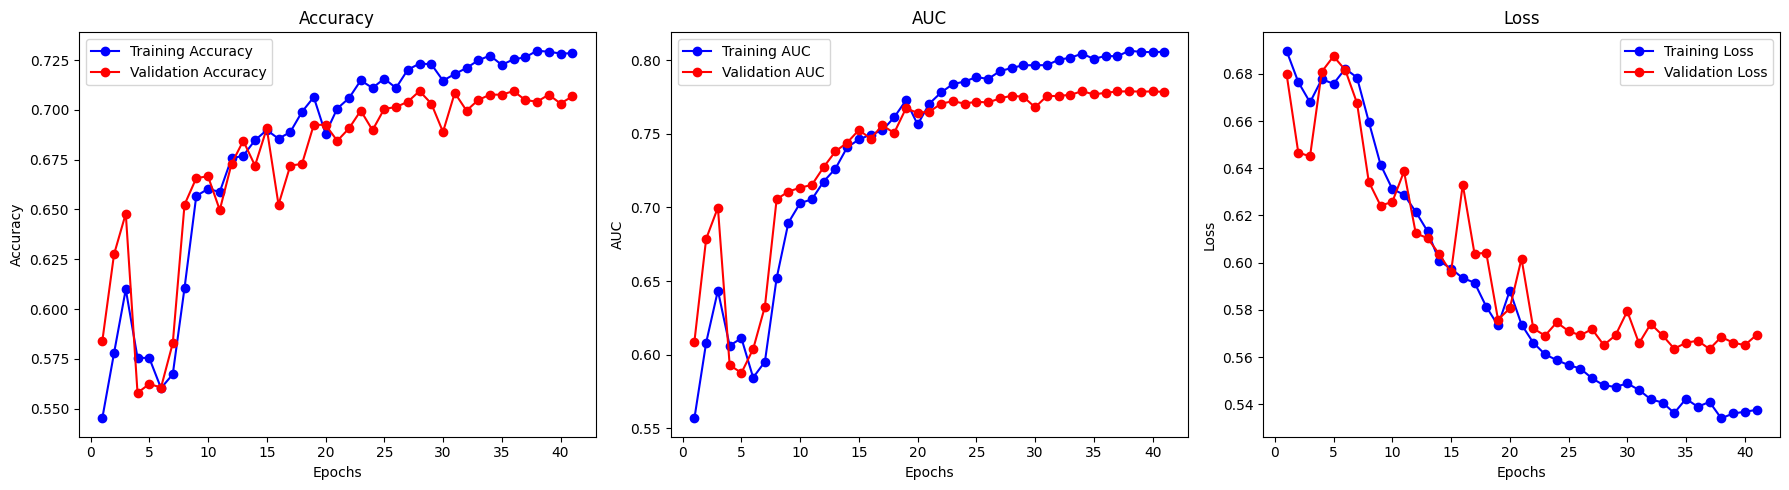

In [12]:
plot_training_metrics(history)

In [15]:
def find_threshold_for_min_recall(y_true, y_pred_proba, min_recall=0.80):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    valid_indices = [i for i, val in enumerate(tpr) if val >= min_recall]
    if not valid_indices:
        print("Nessuna soglia raggiunge la recall minima richiesta.")
        return None
    # Prendi la soglia con il più basso FPR tra quelli con recall >= min_recall
    best_idx = min(valid_indices, key=lambda i: fpr[i])
    threshold = thresholds[best_idx]
    print(f"Soglia con recall >= {min_recall}: {threshold:.3f}")
    return threshold

In [16]:
optimal_threshold = find_threshold_for_min_recall(y_val, model.predict(X_val))

# Fai la predizione sul set di test
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > optimal_threshold).astype("int32")

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Soglia con recall >= 0.8: 0.408
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


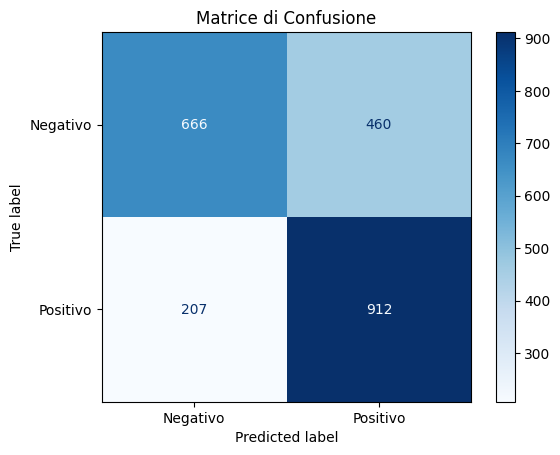

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_classes)
show_confusion_matrix(cm)

In [19]:
#Vediamo i risultati
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

acc = accuracy_score(y_test, y_pred_classes)
auc = roc_auc_score(y_test, y_pred_classes)

print(f"Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")

class_report1 = classification_report(y_test, y_pred_classes, target_names=["Negativo", "Positivo"])
print(class_report1)
class_report1 = classification_report(y_test, y_pred_classes, output_dict=True )


Accuracy: 0.703
AUC: 0.703
              precision    recall  f1-score   support

    Negativo       0.76      0.59      0.67      1126
    Positivo       0.66      0.82      0.73      1119

    accuracy                           0.70      2245
   macro avg       0.71      0.70      0.70      2245
weighted avg       0.71      0.70      0.70      2245



In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
model_path = "/content/drive/MyDrive/chagas_models/CNN_GRU_model.keras"
model.save(model_path)